In [35]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

In [ ]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz, hstack
from sklearn.preprocessing import StandardScaler
import sklearn.utils as sku

# --------------------------------------------------------
# PATHS
# --------------------------------------------------------

DATA_FILE = "/Users/psf728/Desktop/data_nltk.npz"
LABEL_FILE = "Data_files/labels_nltk.txt"
SORT_FILE = "txt_files/speeches_nltk_sort_idx.txt"

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------

LIX_COL = 0
TOPIC_COL = 1
ARTICLE_COL = 2
DATE_COL = 3

# --------------------------------------------------------
# LOAD DATA
# --------------------------------------------------------

data_articles_all = load_npz(DATA_FILE)

labels_articles_all = np.genfromtxt(
    LABEL_FILE,
    delimiter=";",
    dtype=str,
    skip_header=1
)

sort_idx = np.genfromtxt(
    SORT_FILE,
    delimiter="\n",
    dtype=int
)

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

print("Initial data shape:", data_articles_all.shape)
print("Initial number of labels:", labels_articles_all.shape[0])

# --------------------------------------------------------
# KEEP ONLY ARTICLES
# --------------------------------------------------------

article_indicator = labels_articles_all[:, ARTICLE_COL].astype(int)
article_mask = article_indicator == 1

print("\nArticles kept:", article_mask.sum())
print("Speeches removed:", (~article_mask).sum())

data_articles_all = data_articles_all[article_mask]
labels_articles_all = labels_articles_all[article_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# KEEP ONLY TOP X MOST FREQUENT ARTICLE TOPICS
# --------------------------------------------------------

top_x = 10

topics = labels_articles_all[:, TOPIC_COL]

unique_topics, topic_counts = np.unique(
    topics,
    return_counts=True
)

sorted_indices = np.argsort(topic_counts)[::-1]
valid_topics = unique_topics[sorted_indices[:top_x]]

keep_mask = np.isin(topics, valid_topics)

print("\nOriginal number of articles after removing speeches:", data_articles_all.shape[0])
print("Filtered number of articles:", keep_mask.sum())
print("Removed articles outside top topics:", data_articles_all.shape[0] - keep_mask.sum())

print("\nTop topics kept:")
for topic in valid_topics:
    count = np.sum(topics == topic)
    print(f"{topic}: {count}")

data_articles_all = data_articles_all[keep_mask]
labels_articles_all = labels_articles_all[keep_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# ADD LIX SCORE AS FIRST COLUMN
# --------------------------------------------------------

lix_scores = labels_articles_all[:, LIX_COL].astype(np.float32)

lix_column = sparse.csr_matrix(
    lix_scores.reshape(-1, 1)
)

data_articles_all = hstack(
    [lix_column, data_articles_all],
    format="csr"
)

print("Shape after adding LIX:", data_articles_all.shape)

# --------------------------------------------------------
# APPLY COLUMN SORTING / FEATURE COMBING
# --------------------------------------------------------

print("\nData columns before sorting:", data_articles_all.shape[1])
print("Smallest sort index:", sort_idx.min())
print("Largest sort index:", sort_idx.max())

sort_idx = sort_idx[
    sort_idx < data_articles_all.shape[1]
]

print("Number of valid sort indices:", len(sort_idx))

data_articles_all = data_articles_all#[:, sort_idx][:, :10000]

print("Shape after combing:", data_articles_all.shape)

# --------------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------------

scaler = StandardScaler(with_mean=False)

data_articles_all = scaler.fit_transform(
    data_articles_all
)

# --------------------------------------------------------
# CREATE REGRESSION LABELS: ARTICLE DATES
# --------------------------------------------------------

y_years = labels_articles_all[:, DATE_COL].astype(np.float32)

print("\nDate label summary after selecting top topics:")
print("Min year:", y_years.min())
print("Max year:", y_years.max())
print("Mean year:", y_years.mean())
print("Number of unique dates:", len(np.unique(y_years)))

print("\nTopic distribution used for regression dataset:")
filtered_topics = labels_articles_all[:, TOPIC_COL]

for topic in valid_topics:
    count = np.sum(filtered_topics == topic)
    print(f"{topic}: {count}")

# --------------------------------------------------------
# SHUFFLE DATA AND DATE LABELS
# --------------------------------------------------------

data_articles_all, y_years = sku.shuffle(
    data_articles_all,
    y_years,
    random_state=5466542
)

# --------------------------------------------------------
# OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_articles_all.shape)
print("Final number of date labels:", y_years.shape[0])

print("\nExample feature row:")
print(data_articles_all[0])

print("\nExample date label:")
print(y_years[0])

Initial data shape: (780044, 64478)
Initial number of labels: 780044

Articles kept: 775291
Speeches removed: 4753

Original number of articles after removing speeches: 775291
Filtered number of articles: 434564
Removed articles outside top topics: 340727

Top topics kept:
Danmark: 128229
Internationalt: 126256
Politik: 34536
Kultur: 30699
Sport: 29083
Fodbold: 24600
Økonomi: 22715
Forbrug: 13565
Film og tv: 13085
Cykling: 11796
Shape after adding LIX: (434564, 64479)

Data columns before sorting: 64479
Smallest sort index: 0
Largest sort index: 64477
Number of valid sort indices: 64478
Shape after combing: (434564, 64479)

Date label summary after selecting top topics:
Min year: 2000.1052
Max year: 2026.4714
Mean year: 2013.8232
Number of unique dates: 9082

Topic distribution used for regression dataset:
Danmark: 128229
Internationalt: 126256
Politik: 34536
Kultur: 30699
Sport: 29083
Fodbold: 24600
Økonomi: 22715
Forbrug: 13565
Film og tv: 13085
Cykling: 11796

Final data shape: (434

In [37]:
#class MyDataset(Dataset):    
    #def __init__(self, X_data, y_data):
        #self.input = X_data
        #self.truth = y_data
        
    #def __getitem__(self, index):
        #return self.input[index], self.truth[index]
        
    #def __len__ (self):
        #return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
#train_data = MyDataset(data_train, data_train_labels)
#val_data = MyDataset(data_val, data_val_labels)

import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, DATE_COL].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# SPLIT REGRESSION DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_reg,
    y_scaled,
    test_size=0.2,
    random_state=42
)


print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
#print("Test size:", X_test.shape[0])

class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data_reg = MyDataset(X_train, y_train)
val_data_reg = MyDataset(X_val, y_val)

Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 434564
Train size: 347651
Validation size: 86913


In [38]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [39]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [40]:
def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [16, 32, 64]
    )

    Layer1 = trial.suggest_int("Layer1", 128, 512)
    Layer2 = trial.suggest_int("Layer2", 64, 256)
    Layer3 = trial.suggest_int("Layer3", 16, 64)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    n_epochs = 5

    input_dim = X_train.shape[1]

    class OptRegressionModel(nn.Module):

        def __init__(self):
            super(OptRegressionModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, 1)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptRegressionModel().to(device)

    loss_function = nn.MSELoss()

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    train_loader = DataLoader(
        dataset=train_data_reg,
        batch_size=batch_size,
        shuffle=True
    )

    validation_loader = DataLoader(
        dataset=val_data_reg,
        batch_size=batch_size,
        shuffle=False
    )

    best_validation_loss = float("inf")

    epoch_bar = tqdm(
        range(n_epochs),
        desc=f"Trial {trial.number}",
        leave=False,
        unit="epoch"
    )

    for epoch in epoch_bar:

        model_opt.train()
        epoch_training_loss = 0

        for input_batch, truth_batch in train_loader:

            input_batch = input_batch.to(device)
            truth_batch = truth_batch.to(device)

            optimizer.zero_grad()

            predictions = model_opt(input_batch).squeeze()

            loss = loss_function(
                predictions,
                truth_batch
            )

            loss.backward()
            optimizer.step()

            epoch_training_loss += loss.item()

        epoch_training_loss /= len(train_loader)

        model_opt.eval()
        epoch_validation_loss = 0

        with pt.no_grad():

            for input_batch, truth_batch in validation_loader:

                input_batch = input_batch.to(device)
                truth_batch = truth_batch.to(device)

                predictions = model_opt(input_batch).squeeze()

                loss = loss_function(
                    predictions,
                    truth_batch
                )

                epoch_validation_loss += loss.item()

        epoch_validation_loss /= len(validation_loader)

        best_validation_loss = min(
            best_validation_loss,
            epoch_validation_loss
        )

        epoch_bar.set_postfix(
            train_loss=f"{epoch_training_loss:.4f}",
            val_loss=f"{epoch_validation_loss:.4f}",
            best=f"{best_validation_loss:.4f}"
        )

        trial.report(epoch_validation_loss, epoch)

        if trial.should_prune():
            raise opt.exceptions.TrialPruned()

    return best_validation_loss

In [41]:
def progress_callback(study, trial):

    optuna_bar.update(1)

    if study.best_trial is not None:
        optuna_bar.set_postfix(
            best_loss=f"{study.best_value:.4f}",
            best_trial=study.best_trial.number
        )

# HP optimization

In [42]:
class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )

train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)
#test_data_reg = SparseRegressionDataset(X_test, y_test)

In [ ]:
from tqdm.auto import tqdm

n_trials = 5

pruner = opt.pruners.MedianPruner(
    n_startup_trials=2,
    n_warmup_steps=1
)

study = opt.create_study(
    direction="minimize",
    pruner=pruner
)

optuna_bar = tqdm(
    total=n_trials,
    desc="Optuna Trials",
    unit="trial"
)

device = pt.device(
    "cuda" if pt.cuda.is_available() else "cpu"
)

print(device)

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[progress_callback]
)

optuna_bar.close()

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
dropout_rate = best_params["dropout_rate"]
weight_decay = best_params["weight_decay"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

[I 2026-06-07 09:12:07,816] A new study created in memory with name: no-name-a1c5bf9b-0ad4-4e7e-81d7-5f016b544f79


Optuna Trials:   0%|          | 0/5 [00:00<?, ?trial/s]

cpu


Trial 0:   0%|          | 0/5 [00:00<?, ?epoch/s]

/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([3, 1])) that is different to the input size (torch.Size([3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they hav

Trial 1:   0%|          | 0/5 [00:00<?, ?epoch/s]

/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
[I 2026-06-07 13:12:06,022] Trial 1 finished with value: 0.994961239249501 and parameters: {'learning_rate': 0.00015307588504194245, 'batch_size': 64, 'Layer1': 453, 'Layer2': 88, 'Layer3': 40, 'dropout_rate': 0.36078167639917486, 'weight_decay': 2.0761665358924122e-05}. Best is trial 0 with value: 0.9946843971704529.


Trial 2:   0%|          | 0/5 [00:00<?, ?epoch/s]

/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


# Split data before training

In [ ]:
#class MyDataset(Dataset):    
    #def __init__(self, X_data, y_data):
        #self.input = X_data
        #self.truth = y_data
        
    #def __getitem__(self, index):
        #return self.input[index], self.truth[index]
        
    #def __len__ (self):
        #return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
#train_data = MyDataset(data_train, data_train_labels)
#val_data = MyDataset(data_val, data_val_labels)

import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, DATE_COL].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# SPLIT REGRESSION DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X_reg,
    y_scaled,
    test_size=0.1,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp,
    y_train_temp,
    test_size=0.20,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data_reg = MyDataset(X_train, y_train)
val_data_reg = MyDataset(X_val, y_val)

class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )

train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)
test_data_reg = SparseRegressionDataset(X_test, y_test)

Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 434564
Train size: 312885
Validation size: 78222
Test size: 43457


# Training

In [ ]:
import torch as pt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

input_dim = X_train.shape[1]

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
weight_decay = best_params["weight_decay"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

# Lower dropout for regression
dropout_rate = min(best_params["dropout_rate"], 0.15)

class DateRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, Layer1),
            nn.BatchNorm1d(Layer1),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer1, Layer2),
            nn.BatchNorm1d(Layer2),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer2, Layer3),
            nn.GELU(),

            nn.Linear(Layer3, 1)
        )

    def forward(self, x):
        return self.network(x)

device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
model = DateRegressionModel().to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

loss_function = nn.SmoothL1Loss(beta=0.5)

train_loader = DataLoader(train_data_reg, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(val_data_reg, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data_reg, batch_size=batch_size, shuffle=False)

n_epochs = 50
patience = 7

best_val_loss = np.inf
best_state = None
bad_epochs = 0

training_loss = []
validation_loss = []

for epoch in tqdm(range(n_epochs)):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device).view(-1, 1)

        optimizer.zero_grad()
        pred = model(xb)

        loss = loss_function(pred, yb)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with pt.no_grad():
        for xb, yb in validation_loader:
            xb = xb.to(device)
            yb = yb.to(device).view(-1, 1)

            pred = model(xb)
            loss = loss_function(pred, yb)

            val_loss += loss.item()

    val_loss /= len(validation_loader)

    training_loss.append(train_loss)
    validation_loss.append(val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print("Early stopping")
        break

model.load_state_dict(best_state)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001 | train loss 0.6190 | val loss 0.6203
Epoch 002 | train loss 0.6181 | val loss 0.6208
Epoch 003 | train loss 0.6150 | val loss 0.6219
Epoch 004 | train loss 0.6098 | val loss 0.6265
Epoch 005 | train loss 0.6035 | val loss 0.6327
Epoch 006 | train loss 0.5963 | val loss 0.6368
Epoch 007 | train loss 0.5882 | val loss 0.6397
Epoch 008 | train loss 0.5807 | val loss 0.6469
Early stopping


<All keys matched successfully>

In [ ]:
model.eval()
test_predictions_scaled = []

with pt.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        test_predictions_scaled.append(pred)

test_predictions_scaled = np.vstack(test_predictions_scaled)

true_test_years = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
predicted_test_years = y_scaler.inverse_transform(test_predictions_scaled).ravel()

mae = mean_absolute_error(true_test_years, predicted_test_years)
rmse = np.sqrt(mean_squared_error(true_test_years, predicted_test_years))
r2 = r2_score(true_test_years, predicted_test_years)

print(f"MAE  : {mae:.3f} years")
print(f"RMSE : {rmse:.3f} years")
print(f"R²   : {r2:.3f}")

MAE  : 5.344 years
RMSE : 6.429 years
R²   : -0.088


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# LOG LOSS PLOT
# --------------------------------------------------------

eps = 1e-12  # avoid log(0)

log_train_loss = np.log10(np.array(training_loss) + eps)
log_val_loss = np.log10(np.array(validation_loss) + eps)

best_epoch = np.argmin(validation_loss)

plt.figure(figsize=(10, 6))

plt.plot(
    log_train_loss,
    label=f"Train Loss (final={training_loss[-1]:.4f})",
    linewidth=2
)

plt.plot(
    log_val_loss,
    label=f"Validation Loss (best={validation_loss[best_epoch]:.4f})",
    linewidth=2
)

plt.axvline(
    best_epoch,
    linestyle="--",
    alpha=0.7,
    label=f"Best Epoch = {best_epoch + 1}"
)

plt.xlabel("Epoch")
plt.ylabel("log10(Loss)")
plt.title("Training and Validation Log Loss")
plt.grid(alpha=0.3)
plt.legend()

# Display actual losses on plot
plt.text(
    0.02,
    0.98,
    (
        f"Final Train Loss = {training_loss[-1]:.4f}\n"
        f"Best Val Loss = {validation_loss[best_epoch]:.4f}"
    ),
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.tight_layout()
plt.show()

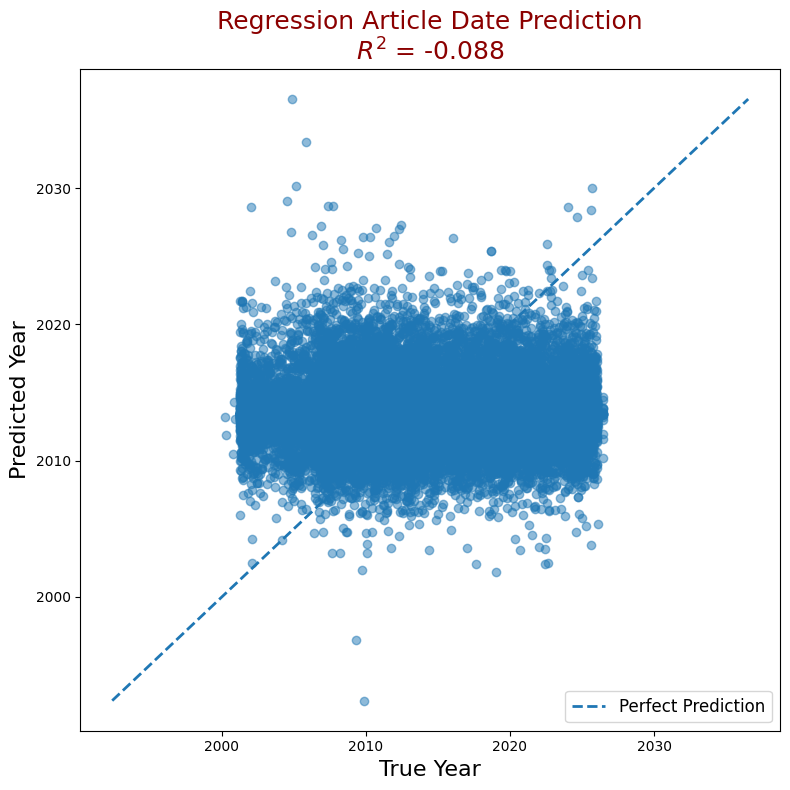

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# --------------------------------------------------------
# TRUE VS PREDICTED YEAR
# --------------------------------------------------------

r2 = r2_score(
    true_test_years,
    predicted_test_years
)

plt.figure(figsize=(8, 8))

plt.scatter(
    true_test_years,
    predicted_test_years,
    alpha=0.5
)

# Perfect prediction line
min_year = min(
    true_test_years.min(),
    predicted_test_years.min()
)

max_year = max(
    true_test_years.max(),
    predicted_test_years.max()
)

plt.plot(
    [min_year, max_year],
    [min_year, max_year],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel(
    "True Year",
    fontsize=16
)

plt.ylabel(
    "Predicted Year",
    fontsize=16
)

plt.title(
    f"Regression Article Date Prediction\n$R^2$ = {r2:.3f}",
    fontsize=18,
    color="darkred"
)

plt.legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "Regression_ArticleDate_TrigramPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# Old training

DATASET SUMMARY
count    434564.000000
mean       2013.823244
std           6.175296
min        2000.105225
25%        2008.996094
50%        2013.091553
75%        2018.860718
max        2026.471436
Name: year_float, dtype: float64

Total articles: 434564
Unique exact dates: 9082
Unique integer years: 27
Unique day estimates: 350

Top 10 most populated years:
year_int
2007    28611
2011    27164
2010    27062
2009    26696
2008    25550
2012    25336
2013    24431
2018    19908
2019    19771
2014    19409
Name: count, dtype: int64

Top repeated exact dates:
year_float
2026.471    194
2011.791    167
2009.839    152
2009.963    148
2009.966    145
2007.955    144
2007.441    139
2007.952    138
2008.264    136
2007.480    135
2007.482    133
2010.230    129
2007.536    128
2009.829    127
2007.805    127
2007.253    127
2009.832    127
2009.433    127
2007.844    126
2006.974    126
Name: count, dtype: int64


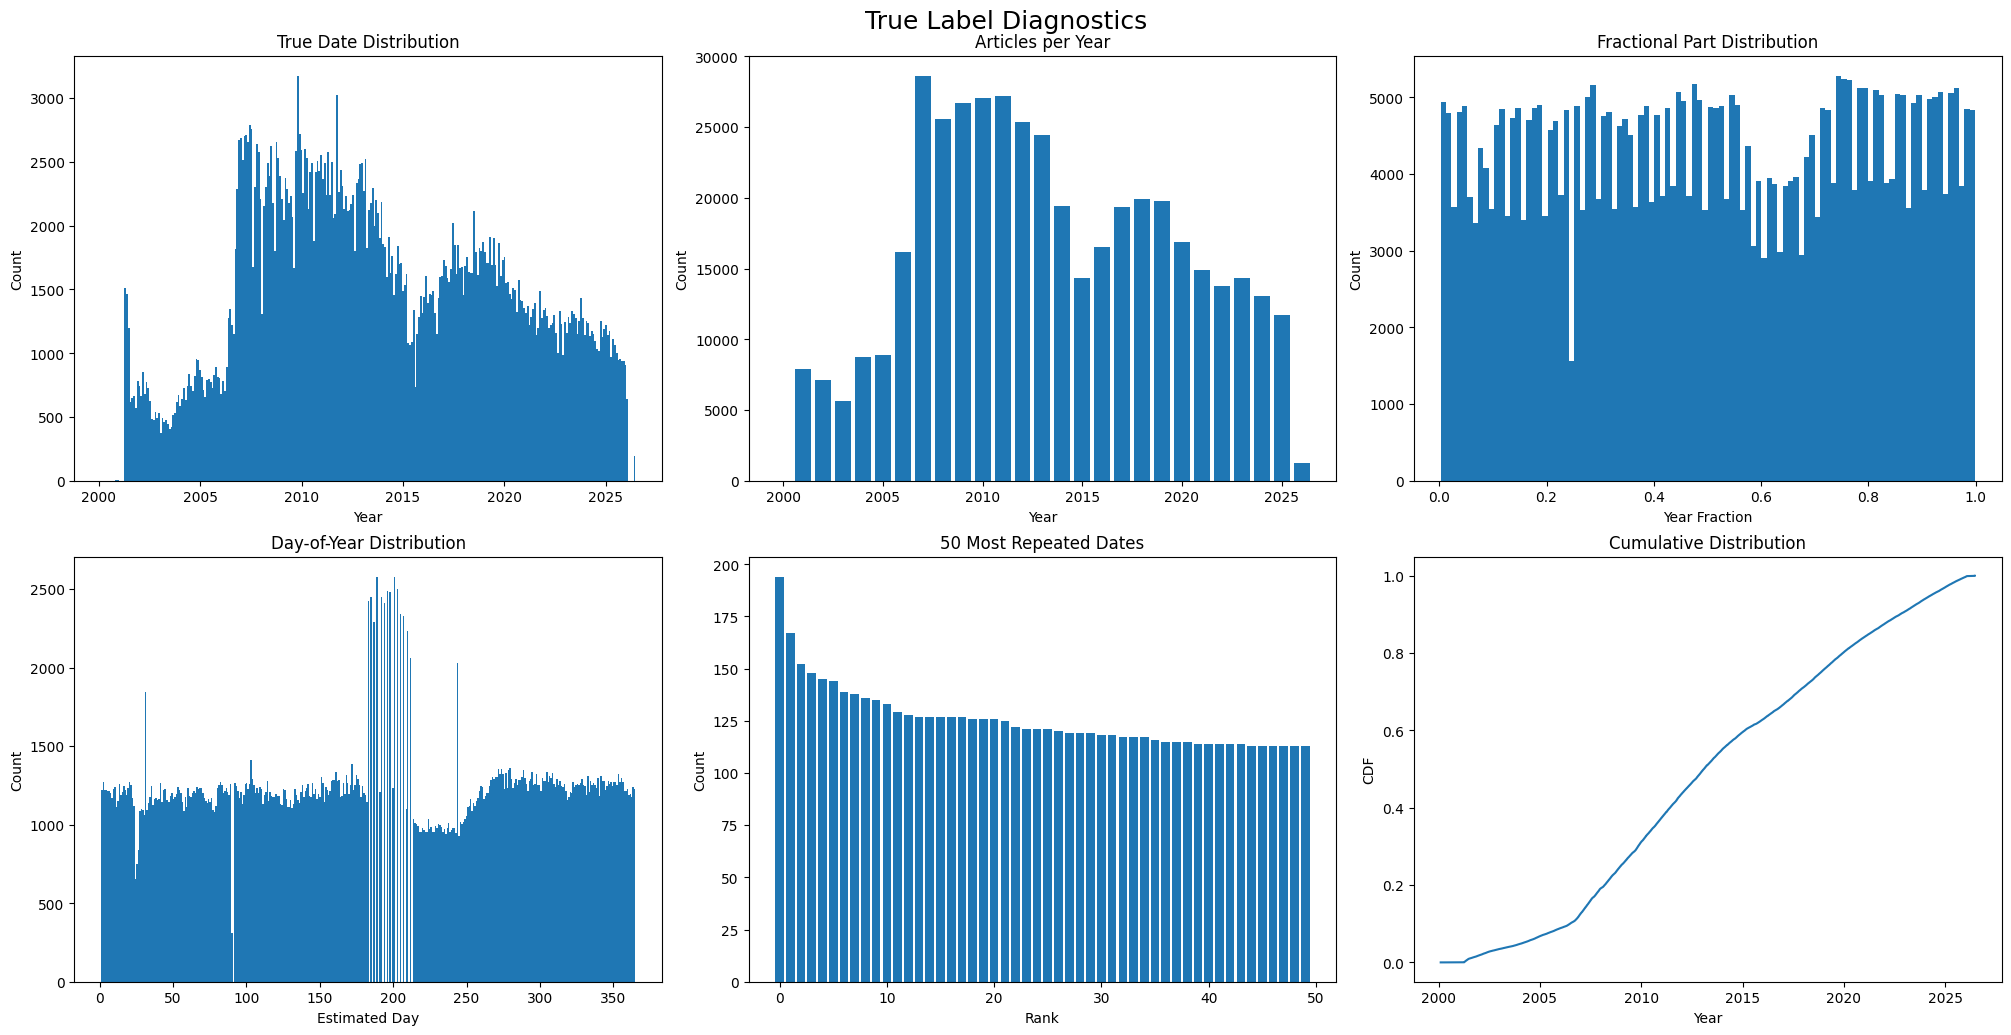


CLUSTERING DIAGNOSTICS
Largest year share : 6.58%
Top 3 years share  : 19.06%
Top 5 years share  : 31.08%
Year-distribution entropy: 4.542
Uniform entropy         : 4.755
Entropy ratio           : 0.955


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# PREPARE DATA
# ==========================================

y = np.asarray(y_years).astype(float)
y = y[~np.isnan(y)]

df = pd.DataFrame({
    "year_float": y,
    "year_int": np.floor(y).astype(int),
    "fraction": y % 1,
    "day_estimate": np.round((y % 1) * 365).astype(int)
})

year_counts = df["year_int"].value_counts().sort_index()
rounded_counts = df["year_float"].round(3).value_counts()

# ==========================================
# SUMMARY STATISTICS
# ==========================================

print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(df["year_float"].describe())

print("\nTotal articles:", len(df))
print("Unique exact dates:", df["year_float"].nunique())
print("Unique integer years:", df["year_int"].nunique())
print("Unique day estimates:", df["day_estimate"].nunique())

print("\nTop 10 most populated years:")
print(year_counts.sort_values(ascending=False).head(10))

print("\nTop repeated exact dates:")
print(rounded_counts.head(20))

# ==========================================
# COMBINED FIGURE
# ==========================================

fig, axs = plt.subplots(
    2, 3,
    figsize=(20, 10),
    constrained_layout=True
)

# ------------------------------------------
# (1) Full date histogram
# ------------------------------------------

axs[0,0].hist(df["year_float"], bins=300)
axs[0,0].set_title("True Date Distribution")
axs[0,0].set_xlabel("Year")
axs[0,0].set_ylabel("Count")

# ------------------------------------------
# (2) Articles per integer year
# ------------------------------------------

axs[0,1].bar(year_counts.index, year_counts.values)
axs[0,1].set_title("Articles per Year")
axs[0,1].set_xlabel("Year")
axs[0,1].set_ylabel("Count")

# ------------------------------------------
# (3) Fractional year distribution
# ------------------------------------------

axs[0,2].hist(df["fraction"], bins=100)
axs[0,2].set_title("Fractional Part Distribution")
axs[0,2].set_xlabel("Year Fraction")
axs[0,2].set_ylabel("Count")

# ------------------------------------------
# (4) Day-of-year distribution
# ------------------------------------------

axs[1,0].hist(df["day_estimate"], bins=365)
axs[1,0].set_title("Day-of-Year Distribution")
axs[1,0].set_xlabel("Estimated Day")
axs[1,0].set_ylabel("Count")

# ------------------------------------------
# (5) Top repeated dates
# ------------------------------------------

top50 = rounded_counts.head(50)

axs[1,1].bar(
    np.arange(len(top50)),
    top50.values
)

axs[1,1].set_title("50 Most Repeated Dates")
axs[1,1].set_xlabel("Rank")
axs[1,1].set_ylabel("Count")

# ------------------------------------------
# (6) CDF of years
# ------------------------------------------

sorted_years = np.sort(df["year_float"])
cdf = np.arange(len(sorted_years)) / len(sorted_years)

axs[1,2].plot(sorted_years, cdf)
axs[1,2].set_title("Cumulative Distribution")
axs[1,2].set_xlabel("Year")
axs[1,2].set_ylabel("CDF")

plt.suptitle(
    "True Label Diagnostics",
    fontsize=18,
    y=1.02
)

plt.show()

# ==========================================
# EXTRA CLUSTERING METRICS
# ==========================================

print("\n" + "="*60)
print("CLUSTERING DIAGNOSTICS")
print("="*60)

largest_year_share = year_counts.max()/len(df)
top3_share = year_counts.sort_values(ascending=False).head(3).sum()/len(df)
top5_share = year_counts.sort_values(ascending=False).head(5).sum()/len(df)

print(f"Largest year share : {largest_year_share:.2%}")
print(f"Top 3 years share  : {top3_share:.2%}")
print(f"Top 5 years share  : {top5_share:.2%}")

# Entropy measure
p = year_counts.values / year_counts.values.sum()
entropy = -(p*np.log2(p)).sum()

print(f"Year-distribution entropy: {entropy:.3f}")

# Compare with uniform distribution
uniform_entropy = np.log2(len(year_counts))
print(f"Uniform entropy         : {uniform_entropy:.3f}")

print(
    f"Entropy ratio           : "
    f"{entropy/uniform_entropy:.3f}"
)

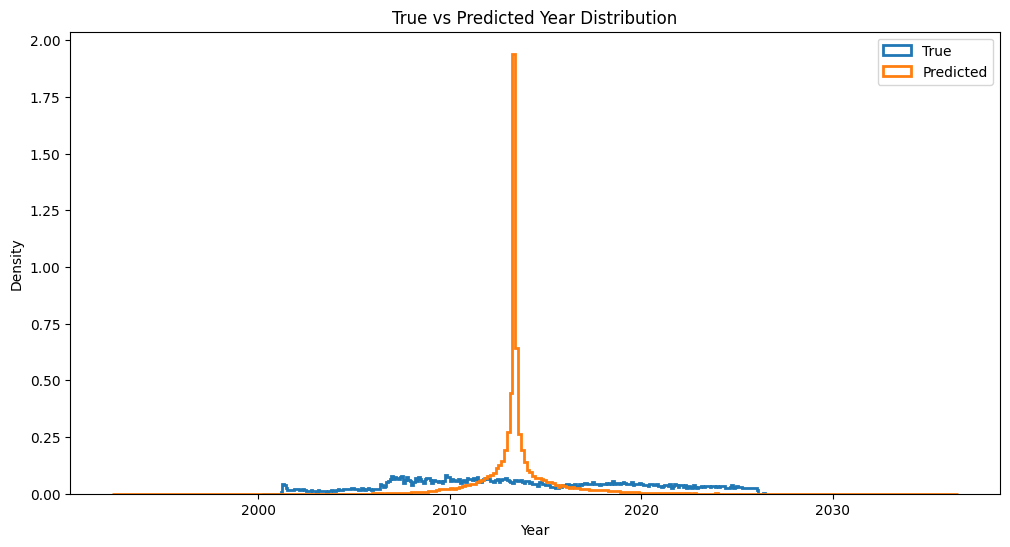

In [ ]:
plt.figure(figsize=(12,6))

plt.hist(
    true_test_years,
    bins=300,
    density=True,
    histtype="step",
    linewidth=2,
    label="True"
)

plt.hist(
    predicted_test_years,
    bins=300,
    density=True,
    histtype="step",
    linewidth=2,
    label="Predicted"
)

plt.xlabel("Year")
plt.ylabel("Density")
plt.title("True vs Predicted Year Distribution")
plt.legend()

plt.show()